# Figure XX homer selection

In [29]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
from matplotlib.patches import Patch
import pyarrow
import openpyxl
from matplotlib import markers

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

In [ ]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Maria'

Plates = {'2026.07.22_homer_selection': ['Rep1_2', 'Rep3_WT','Ctrls'], '2026.08.04_homer_selection': ['Plate1_R1_R2_MOI0.1','Plate2_R3_MOI0.1_GFP_Puro', 'Plate3_R2_R3_MOI0', 'Plate4_ctrls' ]
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'Single_cell_csvs')
        yaml_path.append(base_path/i/j/'Single_cell_csvs'/'wells.yaml')

output_path = rd.rootdir/'output'/'Figure_Ex5_S3_homer'
cache_path = rd.rootdir/'output'/'Figure_Ex5_S3_homer'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
4,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
5,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
6,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [31]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mRuby2-A', 'mRuby2-H','GFP-H','GFP-A', 'iRFP670-A','iRFP670-H', 'FSC-A']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\rushd\flow.py:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(data_list, ignore_index=True).replace(np.NaN, pd.NA)  # type: ignore


In [32]:
display(data)

,moi,cond,puro,biorep,well,population,FSC-A,GFP-A,GFP-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H
0,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,594052,179,113,11302,7908,158.0,146
1,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,639589,19736,13074,17750,13096,49.0,106
2,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,572142,4758,3234,2199,1766,96.0,82
3,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,430421,-35,66,5329,4975,-25.0,64
4,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,432736,3052,2316,4529,4117,154.0,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28495200,0.1,none,10,2,F9,Single Cells,308212,23,60,552,590,254.0,201
28495201,0.1,none,10,2,F9,Single Cells,271648,117,67,519,421,280.0,252
28495202,0.1,none,10,2,F9,Single Cells,299841,146,119,305,315,571.0,558
28495203,0.1,none,10,2,F9,Single Cells,243433,195,128,244,314,350.0,333


In [34]:
channel_list = ['mRuby2-A', 'mRuby2-H','GFP-H','GFP-A', 'iRFP670-A','iRFP670-H']
for channel in channel_list:
    data.loc[data[channel] <=0, channel] = 1

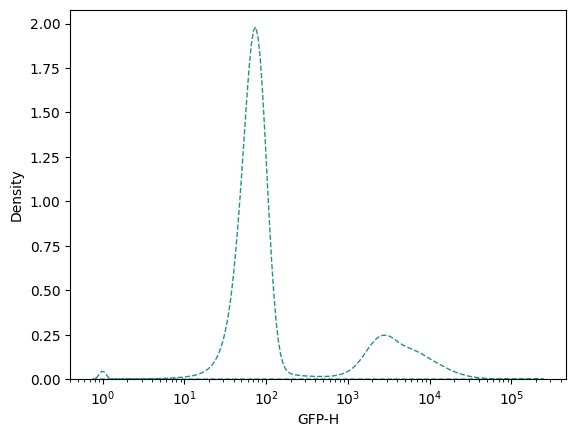

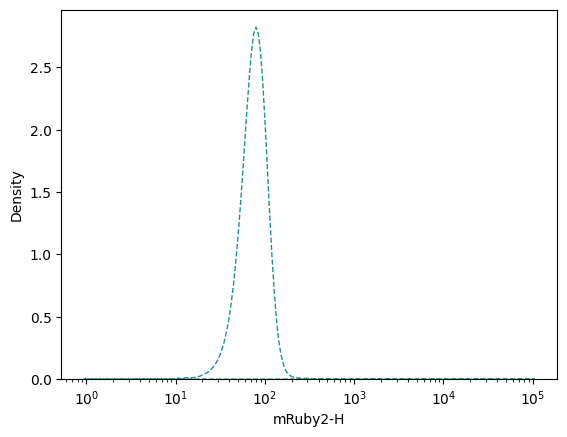

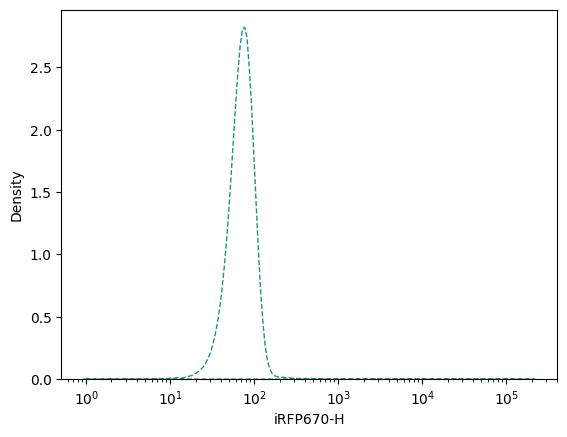

In [35]:
parameters = np.array(['GFP-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['cond'] == 'none')& (data[param] > 0)]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='cond',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [36]:
untransduced = data[(data['moi'] == 0)& (data['cond'] != 'Puro-GFP')]
df_no_mruby = data[data['cond'] == 'none']
gfp_threshold = untransduced['GFP-A'].quantile(0.9995)
mruby_threshold = df_no_mruby['mRuby2-A'].quantile(0.9995)
display(gfp_threshold)

286.0

**iRFP670 gating**

In [37]:
iRFP670_H_thresh = 2.5e2
# Categorize cells based on iRFP670_thresh
data.loc[:, 'iRFP670_cat'] = 'iRFP670-'
data.loc[(data['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Gate infected cells
df_infected = data.loc[(data['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+
group =['cond', 'puro', 'biorep', 'moi']
count_df_reps = data.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

**eGFP gating**

In [38]:
# Categorize cells based on eGFP_thresh
data.loc[:, 'eGFP_cat'] = 'eGFP-'
data.loc[(data['GFP-H'] > gfp_threshold), 'eGFP_cat'] = 'eGFP+'

# Gate infected cells
df_infected = data.loc[(data['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+ of the infected cells
group = ['cond', 'puro', 'biorep', 'moi']
count_df_reps = df_infected.groupby([*group, 'well', 'eGFP_cat'])[
    'GFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

In [40]:
df_infected

,moi,cond,puro,biorep,well,population,FSC-A,GFP-A,GFP-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,iRFP670_cat,eGFP_cat
0,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,594052,179,113,11302,7908,158.0,146,iRFP670+,eGFP-
1,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,639589,19736,13074,17750,13096,49.0,106,iRFP670+,eGFP+
2,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,572142,4758,3234,2199,1766,96.0,82,iRFP670+,eGFP+
3,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,430421,1,66,5329,4975,1.0,64,iRFP670+,eGFP-
4,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,432736,3052,2316,4529,4117,154.0,84,iRFP670+,eGFP+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28495200,0.1,none,10,2,F9,Single Cells,308212,23,60,552,590,254.0,201,iRFP670+,eGFP-
28495201,0.1,none,10,2,F9,Single Cells,271648,117,67,519,421,280.0,252,iRFP670+,eGFP-
28495202,0.1,none,10,2,F9,Single Cells,299841,146,119,305,315,571.0,558,iRFP670+,eGFP-
28495203,0.1,none,10,2,F9,Single Cells,243433,195,128,244,314,350.0,333,iRFP670+,eGFP-


**Uninfected data gated on EGFP**

In [41]:
# Get total counts and percent of GFP-H+ of the infected cells
group = ['cond', 'puro', 'biorep', 'moi']
count_df_reps_control = data.groupby([*group, 'well', 'eGFP_cat'])[
    'GFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps_control = (count_df_reps_control*100/count_df_reps_control.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps_control = count_df_reps_control.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps_control = percent_df_reps_control.loc[(percent_df_reps_control['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps_control = data_eGFP_count_reps_control.loc[(data_eGFP_count_reps_control['eGFP_cat'] == 'eGFP+')]

In [42]:
display(data_eGFP_count_reps_control)

,cond,puro,biorep,moi,well,eGFP_cat,count
0,Puro-GFP,0,1,0.0,A1,eGFP+,4523
2,Puro-GFP,0,1,0.0,B1,eGFP+,4302
4,Puro-GFP,0,1,0.0,C1,eGFP+,5141
6,Puro-GFP,0,1,0.0,D1,eGFP+,5209
8,Puro-GFP,0,2,0.0,E1,eGFP+,4314
...,...,...,...,...,...,...,...
1144,wtNb(Homer),40,3,0.1,D4,eGFP+,15360
1146,wtNb(Homer),40,3,1.0,A4,eGFP+,42352
1148,wtNb(Homer),40,3,1.0,B4,eGFP+,68648
1150,wtNb(Homer),40,3,1.0,C4,eGFP+,42528


Summary stats

In [43]:
summary_dfs = []
groupby_cols = ['cond', 'puro', 'biorep', 'well', 'moi']
sc_count = data.groupby(groupby_cols).size().reset_index(name = "sc_count")
mruby_count = data.groupby(groupby_cols).apply(lambda data: sum(data['mRuby2-A'] > mruby_threshold)).reset_index(name = "mruby_count")
gfp_count = data.groupby(groupby_cols).apply(lambda data: sum(data['GFP-A'] >gfp_threshold)).reset_index(name = "gfp_count")



dfiii = sc_count.merge(mruby_count)
dfii = dfiii.merge(gfp_count)
dfii["purity"] = dfii['gfp_count'] / dfii['sc_count']*100
summary_dfs.append(dfii)

summary_df = pd.concat(summary_dfs, ignore_index=True)

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_40772\1060690904.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mruby_count = data.groupby(groupby_cols).apply(lambda data: sum(data['mRuby2-A'] > mruby_threshold)).reset_index(name = "mruby_count")
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_40772\1060690904.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gfp_count = data.groupby(groupby_co

In [44]:
display(summary_df)

,cond,puro,biorep,well,moi,sc_count,mruby_count,gfp_count,purity
0,Puro-GFP,0,1,A1,0.0,64229,1,5149,8.016628
1,Puro-GFP,0,1,B1,0.0,61378,5,4801,7.822021
2,Puro-GFP,0,1,C1,0.0,66851,0,5769,8.629639
3,Puro-GFP,0,1,D1,0.0,69789,0,5849,8.380977
4,Puro-GFP,0,2,E1,0.0,61890,5,4805,7.763774
...,...,...,...,...,...,...,...,...,...
572,wtNb(Homer),40,3,D4,1.0,91640,61526,72477,79.088826
573,wtNb(Homer),40,3,E4,0.0,68373,3059,22,0.032176
574,wtNb(Homer),40,3,F4,0.0,51260,2208,23,0.044869
575,wtNb(Homer),40,3,G4,0.0,58299,2935,25,0.042882


Plotting parameters

In [45]:
#universal plotting parameters
yaxis_fontsize = 14
xaxis_fontsize = 14
title_fontsize = 16
legend_title_fontsize = 14
legend_fontsize = 12
alpha_main = 0.8
alpha_biorep = 0.45
dot_size = 7
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456', 'black']

## (%) EGFP graphs

**(Figure S3B) MOI 0.1 Homer1 dot plot graph**

none_0 vs. none_10: ****
Puro-GFP_0 vs. Puro-GFP_40: ****
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: **
wtNb(Homer)_0 vs. wtNb(Homer)_40: ****
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****


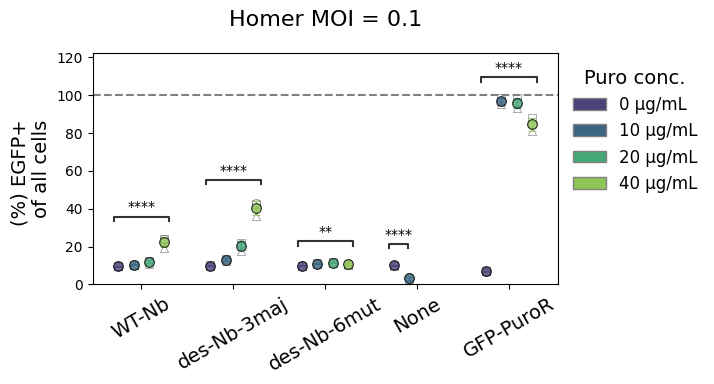

In [47]:

hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'percent'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut",
    "none",
    "Puro-GFP"
]

subset = data_eGFP_percent_reps_control[
    (data_eGFP_percent_reps_control['moi'] == 0.1) |
    (data_eGFP_percent_reps_control['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(%) EGFP+ \nof all cells', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3maj',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, 
    fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 0.1',
    fontsize=title_fontsize,
    pad=20
)

# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
    (('Puro-GFP', 0), ('Puro-GFP', 40)),
    (('none', 0), ('none', 10))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


#fig.tight_layout()

plottitle = 'Figure_XX_homer_MOI0.1_purity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**(Ext Fig 5B) MOI 1 Homer1 dot plot graph**

none_0 vs. none_40: ns
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: ****
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****


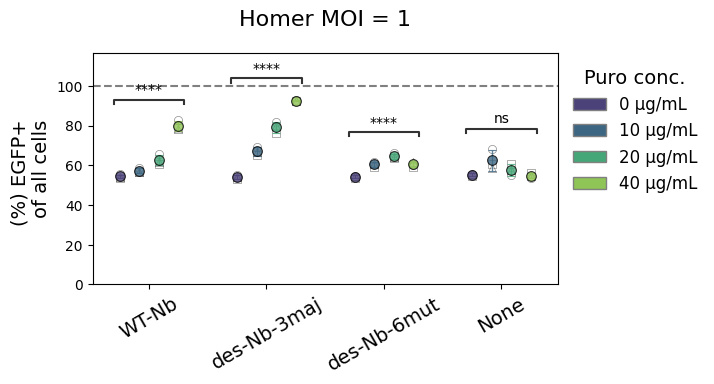

In [48]:

hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'percent'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut",
    "none"
]

subset = data_eGFP_percent_reps_control[
    (data_eGFP_percent_reps_control['moi'] == 1) 
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(%) EGFP+ \nof all cells', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')
ax.set_title(
    'Homer MOI = 1',
    fontsize=title_fontsize,
    pad=20
)

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3maj',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, 
    fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
    (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


#fig.tight_layout()

plottitle = 'Figure_XX_homer_MOI1_purity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## (#)EGFP cell graphs

**(Figure S3C) #GFP cells for Homer1 MOI 0.1**

desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: ****
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ns


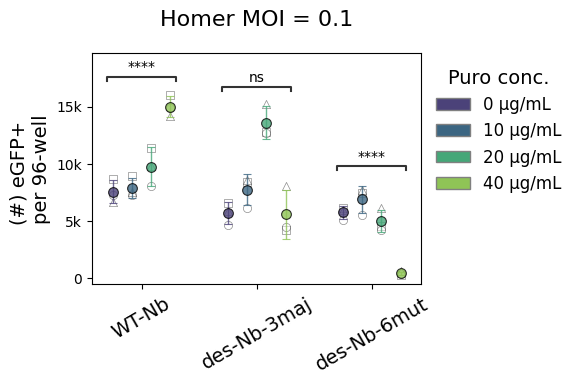

In [49]:

hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'count'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut"
]

subset = data_eGFP_count_reps_control[
    (data_eGFP_count_reps_control['moi'] == 0.1) |
    (data_eGFP_count_reps_control['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.25,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) eGFP+ \nper 96-well', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_title(
    'Homer MOI = 0.1',
    fontsize=title_fontsize,
    pad=20
)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3maj',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)




# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40))
    # (('Puro-GFP', 0), ('Puro-GFP', 40)),
    # (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


#fig.tight_layout()

plottitle = 'Figure_XX_homer_MOI0.1_EGFP_count_cells.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**(Ext Fig 5C) #EGFP cell count Homer1 MOI 1**

desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: **
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: *


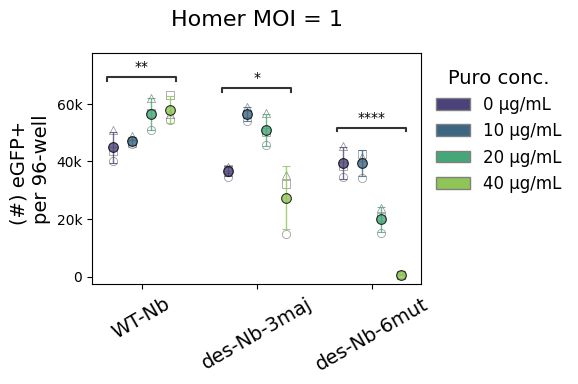

In [51]:

hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'count'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut"
]

subset = data_eGFP_count_reps_control[
    (data_eGFP_count_reps_control['moi'] == 1) |
    (data_eGFP_count_reps_control['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.25,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) eGFP+ \nper 96-well', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_title(
    'Homer MOI = 1',
    fontsize=title_fontsize,
    pad=20
)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3maj',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)




# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40))
    # (('Puro-GFP', 0), ('Puro-GFP', 40)),
    # (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


# fig.tight_layout()

plottitle = 'Figure_XX_homer_MOI1_EGFP_count_cells.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## (#)Transduced cells graphs

**(Figure S3D) # Transduced cells Homer1 MOI 0.1**

desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: ns
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****


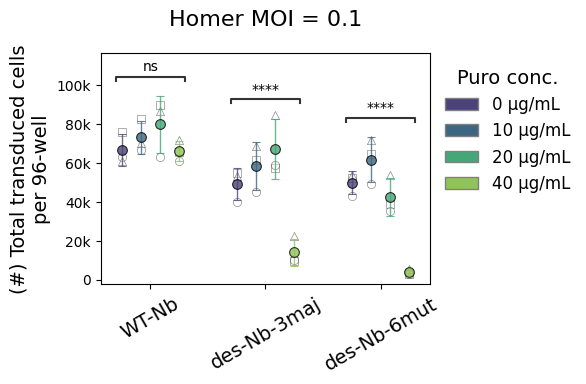

In [52]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'count'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut"
]

subset = data_iRFP670_count_reps[
    (data_iRFP670_count_reps['moi'] == 0.1) |
    (data_iRFP670_count_reps['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.25,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) Total transduced cells\nper 96-well', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3maj',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 0.1',
    fontsize=title_fontsize,
    pad=20
)

# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)



# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40))
    # (('Puro-GFP', 0), ('Puro-GFP', 40)),
    # (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


# fig.tight_layout()

plottitle = 'Figure_XX_homer__MOI0.1_transduced_cells.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**(Ext Fig 5D) # Transduced cells Homer 1 MOI 1**

desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: ns
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****


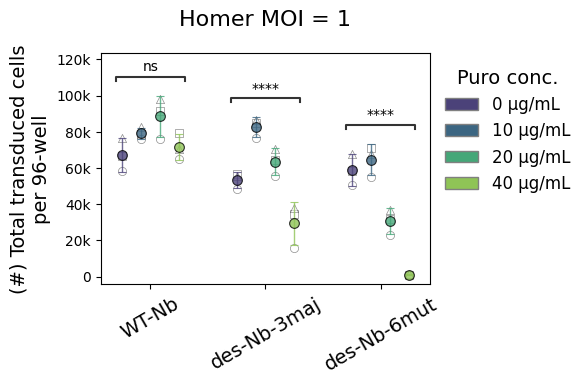

In [53]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'count'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut"
]

subset = data_iRFP670_count_reps[
    (data_iRFP670_count_reps['moi'] == 1) |
    (data_iRFP670_count_reps['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.25,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) Total transduced cells\nper 96-well', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3maj',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 1',
    fontsize=title_fontsize,
    pad=20
)

# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)



# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40))
    # (('Puro-GFP', 0), ('Puro-GFP', 40)),
    # (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


# fig.tight_layout()

plottitle = 'Figure_XX_homer__MOI1_transduced_cells.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Contours

**(Figure S3E) Joint contours Homer1 MOI 0.1**

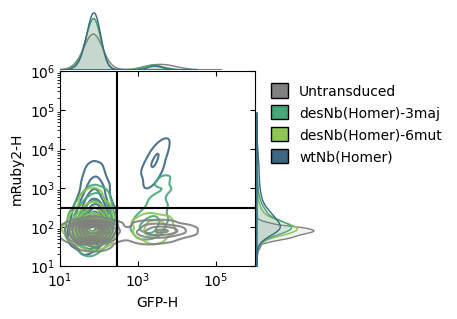

In [54]:
# General plotting params
x = "GFP-H"
y = "mRuby2-H"
hue = "cond"


hue_order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut",
    "none"
]

# Conditions

palette = {'none': 'grey', 
'wtNb(Homer)':'#3C6682', 
'desNb(Homer)-3maj':'#45A778', 
'desNb(Homer)-6mut':'#8FC456'}

# Conditions
data_new = df_infected[(df_infected['GFP-H'] > 0 ) & (df_infected['mRuby2-H'] > 0) & (df_infected['moi'] == 0.1) & (df_infected['puro'] == 0)]
untransfected = data[(data['GFP-H'] > 0) & (data['mRuby2-H'] > 0) & (data['puro'] == 0) & (data['cond'] == 'none') ]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new,untransfected])
small_data= small_data.groupby('cond').sample(n=1000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)


# from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=1,
          label='Untransduced'),
    Patch(facecolor='#45A778', edgecolor='black', linewidth=1,
          label='desNb(Homer)-3maj'),
    Patch(facecolor='#8FC456', edgecolor='black', linewidth=1,
          label='desNb(Homer)-6mut'),
              Patch(facecolor='#3C6682', edgecolor='black', linewidth=1,
          label='wtNb(Homer)')
]


ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(gfp_threshold, 0, 1, color='black')
ax_scatter.axhline(300, 0, 1, color='black')


# fig.tight_layout()  # Helps improve white spacing

plottitle = 'homer_contour_MOI0.1.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**(Ext Fig 5E) Joint contours Homer1 MOI 1**

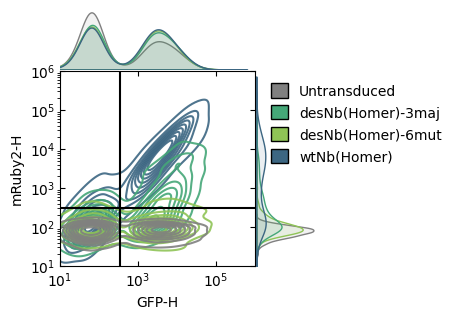

In [25]:
# General plotting params
x = "GFP-H"
y = "mRuby2-H"
hue = "cond"


hue_order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut",
    "none"
]

# Conditions

palette = {'none': 'grey', 
'wtNb(Homer)':'#3C6682', 
'desNb(Homer)-3maj':'#45A778', 
'desNb(Homer)-6mut':'#8FC456'}

# Conditions
data_new = df_infected[(df_infected['GFP-H'] > 0 ) & (df_infected['mRuby2-H'] > 0) & (df_infected['moi'] == 1) & (df_infected['puro'] == 0)]
untransfected = data[(data['GFP-H'] > 0) & (data['mRuby2-H'] > 0) & (data['puro'] == 0) & (data['cond'] == 'none') ]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new,untransfected])
small_data= small_data.groupby('cond').sample(n=1000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)


# from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=1,
          label='Untransduced'),
    Patch(facecolor='#45A778', edgecolor='black', linewidth=1,
          label='desNb(Homer)-3maj'),
    Patch(facecolor='#8FC456', edgecolor='black', linewidth=1,
          label='desNb(Homer)-6mut'),
              Patch(facecolor='#3C6682', edgecolor='black', linewidth=1,
          label='wtNb(Homer)')
]


ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(gfp_threshold, 0, 1, color='black')
ax_scatter.axhline(300, 0, 1, color='black')


# fig.tight_layout()  # Helps improve white spacing

plottitle = 'homer_contour_MOI1.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')